# **Modeling and Evaluation ** #

## Objectives

* Answering Business Requirement 2:
  * Predict whether a leaf is infected with powdery mildew or not

## Inputs

* /workspaces/mildew-detection/inputs/datasets/cherry-leaves/test
* /workspaces/mildew-detection/inputs/datasets/cherry-leaves/validation
* /workspaces/mildew-detection/inputs/datasets/cherry-leaves/train

## Outputs

* Generate images distribution for the train, test, and validation sets
* Image augmentation
* Class indicies to change prediciton inference in labels
* Create and train Machine Learning Model
* Save the model
* Learning curve plot to show model performance
* Model evaluation on pickle file
* Create a predicition using a random image file

## Additional Comments

* In case you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Import Packages #

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from matplotlib.image import imread

2025-08-31 15:56:12.017991: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 15:56:12.058513: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/mildew-detection/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/mildew-detection'

## Set Input Directories ##

Set train, validation and test paths

In [5]:
my_data_dir = "inputs/datasets/cherry-leaves"
train_path = my_data_dir + "/train"
val_path = my_data_dir + "/validation"
test_path = my_data_dir + "/test"

## Set Output Directory ##

In [6]:
version = "v1"
file_path = f"outputs/{version}"
if "outputs" in os.listdir(current_dir) and version in os.listdir(current_dir + "/outputs"):
    print("Old version is already available. Create a new version")
    pass
else:
    os.makedirs(name=file_path)

Old version is already available. Create a new version


## Set Labels ##

In [7]:
labels = os.listdir(train_path)
print(f"The Project Labels are {labels}")

The Project Labels are ['powdery_mildew', 'healthy']


## Set Image Shape ##

In [8]:
import joblib
version = "v1"
image_shape = joblib.load(filename=f"outputs/{version}/image_shape.pk1")
image_shape

(160, 160, 3)

---

# Number of images in Train, Test and Validation #

In [23]:
data = {
    "Set": [],
    "Label": [],
    "Frequency": []
}
for folder in ["train", "validation", "test"]:
    for label in labels:
        row = {
            "Set": folder,
            "Label": label,
            "Frequency": int(len(os.listdir(my_data_dir + "/" + folder + "/" + label)))
        }
        for key, value in row.items():
            data[key].append(value)
        print(f"* {folder} - {label}: {len(os.listdir(my_data_dir + "/" + folder + "/" + label))} images")
df_freq = pd.DataFrame(data)

* train - powdery_mildew: 1472 images
* train - healthy: 1472 images
* validation - powdery_mildew: 210 images
* validation - healthy: 210 images
* test - powdery_mildew: 422 images
* test - healthy: 422 images


Create a bargraph to show how the data is split

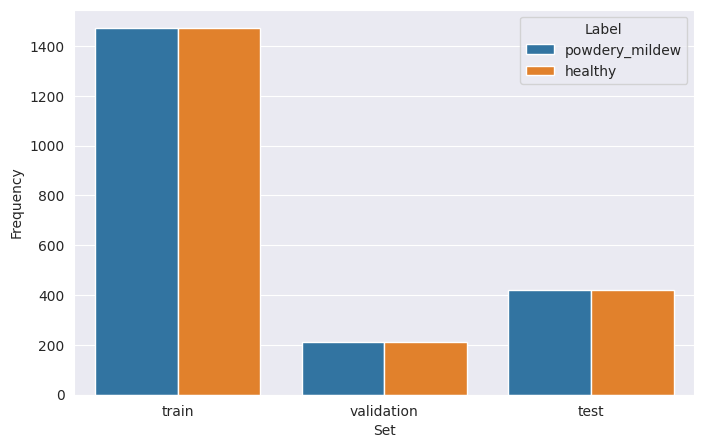

In [24]:
sns.set_style("darkgrid")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_freq, x="Set", y="Frequency", hue="Label")
plt.savefig(f"{file_path}/labels_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

---

# Image Data Augmentation #

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Initialise ImageDataGenerator ##

In [26]:
augmented_image_data = ImageDataGenerator(rotation_range=25,
                                          width_shift_range=0.10,
                                          height_shift_range=0.10,
                                          shear_range=0.1,
                                          zoom_range=0.1,
                                          horizontal_flip=True,
                                          vertical_flip=True,
                                          fill_mode="nearest",
                                          rescale=1./255)

## Batch Size ##

In [27]:
batch_size = 35

## Augment Image DataSets ##

Training Image DataSet

In [29]:
train_set = augmented_image_data.flow_from_directory(train_path,
                                                     target_size=image_shape[:2],
                                                     color_mode="rgb",
                                                     batch_size=batch_size,
                                                     class_mode="binary",
                                                     shuffle=True)
train_set.class_indices

Found 2944 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

Validation Image DataSet

In [30]:
validation_set = ImageDataGenerator(rescale=1./255).flow_from_directory(val_path,
                                                     target_size=image_shape[:2],
                                                     color_mode="rgb",
                                                     batch_size=batch_size,
                                                     class_mode="binary",
                                                     shuffle=False)
validation_set.class_indices

Found 420 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

Test Image DataSet

In [31]:
test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(test_path,
                                                     target_size=image_shape[:2],
                                                     color_mode="rgb",
                                                     batch_size=batch_size,
                                                     class_mode="binary",
                                                     shuffle=False)
test_set.class_indices

Found 844 images belonging to 2 classes.


{'healthy': 0, 'powdery_mildew': 1}

# Plot Augmented Images #

Training Images

(35, 160, 160, 3)


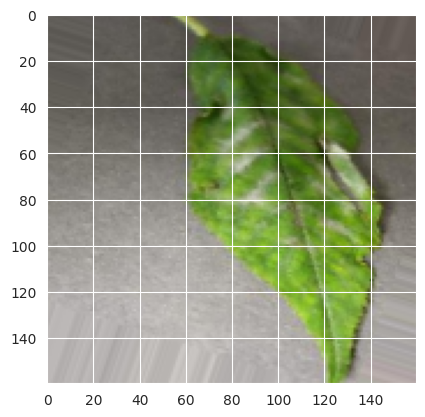

(35, 160, 160, 3)


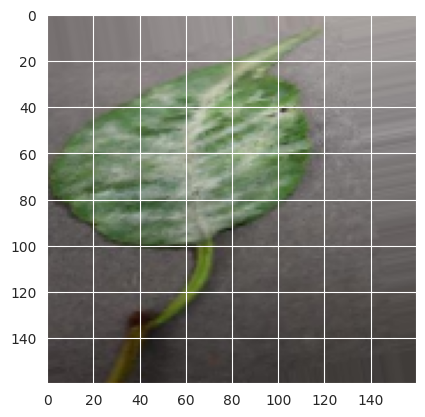

(35, 160, 160, 3)


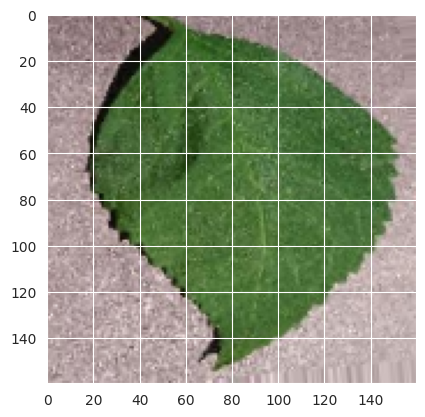

In [33]:
for _ in range(3):
    img, label = next(train_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.show()

Validation Images

(35, 160, 160, 3)


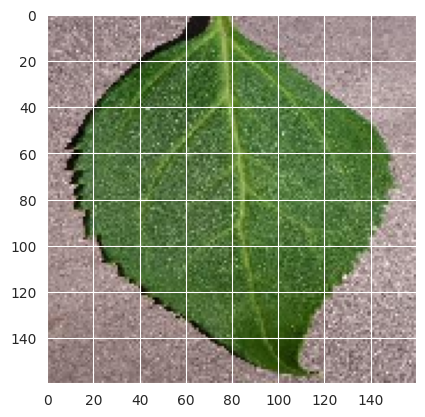

(35, 160, 160, 3)


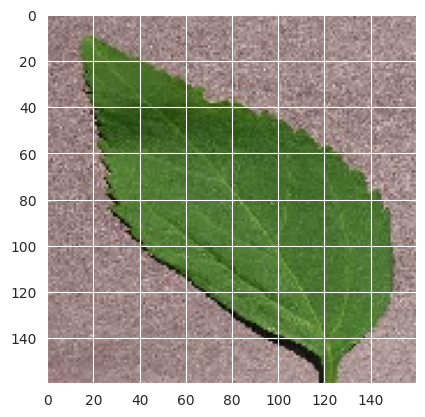

(35, 160, 160, 3)


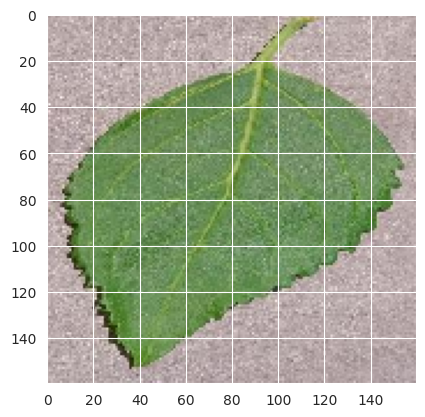

In [35]:
for _ in range(3):
    img, label = next(validation_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.show()

Test Set

(35, 160, 160, 3)


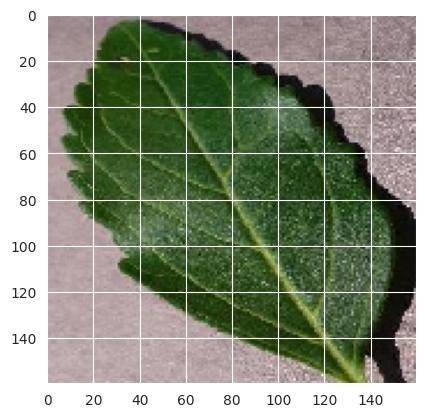

(35, 160, 160, 3)


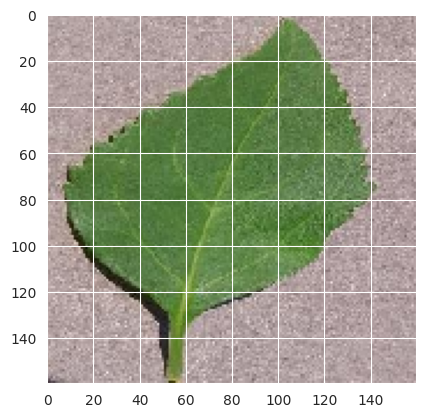

(35, 160, 160, 3)


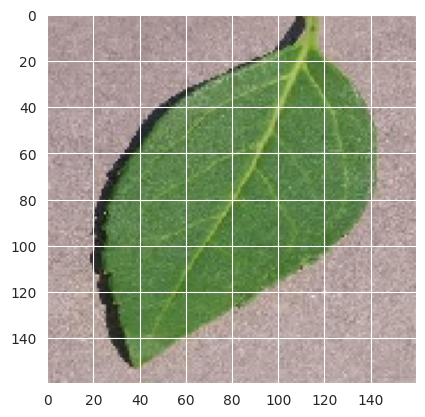

In [36]:
for _ in range(3):
    img, label = next(test_set)
    print(img.shape)
    plt.imshow(img[0])
    plt.show()

# Save class_indicies #

In [38]:
joblib.dump(value=train_set.class_indices, filename=f"{file_path}/class_indicies.pk1")

['outputs/v1/class_indicies.pk1']

---

# Model Creation #

## Import Model Packages ##

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

## Create Model ##

In [41]:
def create_tf_model():
    model = Sequential()
    model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=image_shape, activation="relu",))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=image_shape, activation="relu",))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), input_shape=image_shape, activation="relu",))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

## Model Summary ##

In [42]:
create_tf_model().summary()

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,710,785 (10.34 MB)

 Trainable params: 2,710,785 (10.34 MB)

 Non-trainable params: 0 (0.00 B)

## Early Stopping ##

In [48]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", patience=5)

## Fit Model for Model Training ##

In [49]:
model = create_tf_model()
model.fit(train_set,
          epochs=20,
          steps_per_epoch=len(train_set.classes) // batch_size,
          validation_data = validation_set,
          callbacks = [early_stop],
          verbose = 1
)

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 49s 553ms/step - accuracy: 0.8670 - loss: 0.2645 - val_accuracy: 0.9976 - val_loss: 0.0072
Epoch 2/20
 1/84 ━━━━━━━━━━━━━━━━━━━━ 31s 374ms/step - accuracy: 1.0000 - loss: 0.0206

/home/cistudent/.local/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 47s 547ms/step - accuracy: 0.9935 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 79s 550ms/step - accuracy: 0.9873 - loss: 0.0405 - val_accuracy: 0.9976 - val_loss: 0.0069
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9976 - val_loss: 0.0071
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 543ms/step - accuracy: 0.9935 - loss: 0.0222 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 1.0000 - loss: 0.0236 - val_accuracy: 0.9976 - val_loss: 0.0070


## Model Save ##

In [50]:
model.save("my_model.keras")

---

# Model Performance #

## Model Learning Curve #

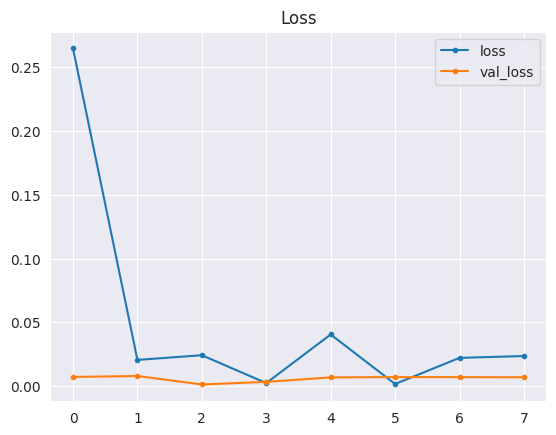

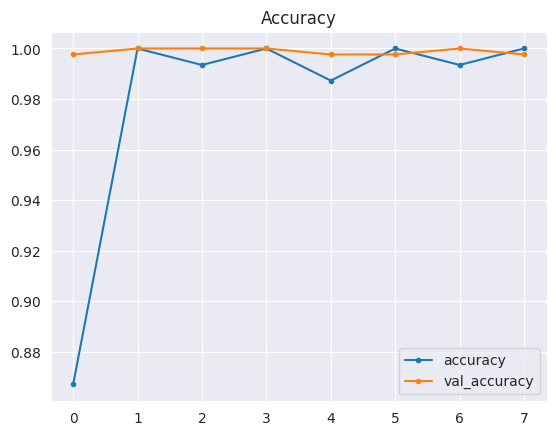

In [51]:
losses = pd.DataFrame(model.history.history)
sns.set_style("darkgrid")
losses[["loss", "val_loss"]].plot(style=".-")
plt.title("Loss")
plt.savefig(f"{file_path}/model_training_losses.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n")
losses[["accuracy", "val_accuracy"]].plot(style=".-")
plt.title("Accuracy")
plt.savefig(f"{file_path}/model_training_acc.png", bbox_inches="tight", dpi=150)
plt.show()

# Section 1

Section 1 content

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
    # create here your folder
    # os.makedirs(name='')
except Exception as e:
    print(e)
